In [32]:
import os
import osmnx as ox
import networkx as nx
import geopandas as gpd
import networkit as nk
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
# Utilized to view all columns in the info tables

import pandas as pd
pd.set_option('display.max_columns', None)

In [ ]:
# List used for reference of cities and their populations, as well as a dictionary to store measures for each city

cities = ['Indianapolis', 'Fort Wayne', 'Evansville', 'South Bend', 'Fishers', 'Carmel', 'Bloomington', 'Hammond', 'Noblesville', 'Lafayette']
populations = {'Indianapolis': 895436, 'Fort Wayne': 268589, 'Evansville': 116116, 'South Bend': 103085,
               'Fishers': 102337, 'Carmel': 101651, 'Bloomington': 80049, 'Hammond': 76768, 'Noblesville': 73362,
               'Lafayette': 71159}
city_measures = {}

In [ ]:
# Helper fucntion to load the graph and perform spatial joins to get info for nodes and edges

def graph_loader(place):
  tags = {"building": True, "amenity": True, "shop": True} # Tags to get building, amenity, and shop info for nodes
  place = f"{place}, Indiana, USA" # Format the place name for OSMnx
  gdf_features = ox.features_from_place(place, tags) # Get the features for the place with the specified tags

  G = ox.graph_from_place(place, network_type="all") # Load the graph for the place with all types of roads

  gdf_nodeinfo = gdf_features[gdf_features.geometry.type == 'Point'] # Get the point features (nodes) from the features GeoDataFrame
  gdf_nodes, gdf_edges = ox.graph_to_gdfs(G) # Convert the graph to GeoDataFrames for nodes and edges

  nodes_proj = ox.projection.project_gdf(gdf_nodes) # Project the nodes GeoDataFrame to a metric coordinate system
  buildings_proj = ox.projection.project_gdf(gdf_nodeinfo)

  # Join nodes to the nearest building
  # distance_col creates a column showing how far away the building is in meters
  joined_nodes_gdf = gpd.sjoin_nearest(
      nodes_proj,
      buildings_proj,
      how="left",
      distance_col="dist_meters")
  joined_nodes_gdf = joined_nodes_gdf.dropna(axis=1, how='all')

  # Same process for edges
  edges_proj = ox.projection.project_gdf(gdf_edges)

  gdf_edgeinfo = gdf_features[gdf_features.geometry.type == 'Point']
  buildings_proj = ox.projection.project_gdf(gdf_edgeinfo)

  joined_edges_gdf = gpd.sjoin_nearest(
      edges_proj,
      buildings_proj,
      how="left",
      distance_col="dist_to_building_meters")
  joined_edges_gdf = joined_edges_gdf.dropna(axis=1, how='all')

  print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}\n") # Summary of the graph
  return G, joined_nodes_gdf, joined_edges_gdf

In [ ]:
# Function to compute degree and betweenness centrality for a graph, and return the top 5 nodes for each measure, as well as the node with the highest betweenness centrality and its score

def degree_and_betweenness(G):
  sorted_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)
  top_degrees = sorted_nodes[:5] # Top 5 nodes
  print(top_degrees)

  # Extra code for degree centrality
  deg_centrality = nx.degree_centrality(G)
  top_degree_c = sorted(deg_centrality, key=deg_centrality.get, reverse=True)[:5]
  top_degrees_c = []

  for node in top_degree_c:
      top_degrees_c.append((node, deg_centrality[node]))

  n = 100 # Number of nodes used for betweenness centrality approximation due to computational intensity
  # Important note that betweenness cnetality may differ slightly between runs due to the random sampling of nodes for approximation
  # In my testing the top node for betweenness centrality was consistent across runs, but the scores may differ slightly
  # Regardless, the top node for betweenness centrality is the most important result for this measure and it should be consistent across runs
  bet_cent = nx.betweenness_centrality(G, k=n)
  max_node = max(bet_cent, key=bet_cent.get)
  return top_degrees, top_degrees_c, bet_cent, max_node, bet_cent[max_node]

In [ ]:
# Function to compute betweenness centrality using KADABRA approximation, and return the top nodes with their scores
# Used as an alternative option to the exact betweenness centrality calculation with KADABRA being specialized for large graphs
# Note: KADABRA is a randomized algorithm, so results may vary between runs. Setting a random seed ensures reproducibility.

def kadabra_betweenness_finder(G):
  random.seed(7)
  G_undirected = G.to_undirected() # Graph must be undirected for KADABRA
  G_nk = nk.nxadapter.nx2nk(G_undirected)

  # NetworkX nodes are mapped to NetworKit IDs 0 to n-1 in order
  # Create a mapping from original node labels to NetworKit IDs and vice versa
  # This is to make sure the nodes returned by KADABRA can be mapped back to the original graph's node labels
  node_list = list(G_undirected.nodes())
  id_map = {node_label: i for i, node_label in enumerate(node_list)}
  inverse_map = {i: node_label for i, node_label in enumerate(node_list)}

 # Running KADABRA for top 5 nodes
  kadabra = nk.centrality.KadabraBetweenness(G_nk, k=5)
  kadabra.run()

  # Finding the original node labels for the top nodes returned by KADABRA and their scores
  true_nodes = []
  for nk_id, score in kadabra.ranking():
      original_label = inverse_map[nk_id]
      true_nodes.append((original_label, score))
  return true_nodes

In [ ]:
# Extra function for cleaning speed values from the edge attributes
# This is if the maxspeed column has multiple values or is in a string format

def clean_speed(val):
    if isinstance(val, list): # Extract numbers from list and take the average
        nums = [float(s.split()[0]) for s in val if str(s).split()[0].isdigit()]
        return np.mean(nums) if nums else np.nan # Return NaN if no valid numbers found
    elif isinstance(val, str): # Extract the first number from the string
        s = val.split()[0]
        return float(s) if s.isdigit() else np.nan
    return val

In [ ]:
# Function to compute various statistics about the edges in the graph

def edge_statistics(G, city_edges):
  if 'highway_left' not in city_edges.columns: # If the 'highway_left' column doesn't exist, create it by applying a function to the 'highway' column
    city_edges['highway_left'] = city_edges['highway'].apply(lambda x: x if isinstance(x, list) else [x])
  top_highway = city_edges['highway_left'].explode().value_counts().idxmax() # Explodes the list if it has several types
  count = city_edges['highway_left'].explode().value_counts().max() # Count of the most common highway type
  one_way_ratio = city_edges['oneway'].value_counts(normalize=True).get(True, 0)
  avg_max_speed = city_edges['maxspeed'].apply(clean_speed).mean()
  avg_length = city_edges['length'].mean() # Average length in meters of the edges in the graph
  return top_highway, count, one_way_ratio, avg_max_speed, avg_length

The following sections of code are for running the functions for the different cities and gathering the top nodes. It's separated as to not incur a long execution time over multiple cities. The code blocks follow a pattern of data collection and then data recording for the 10 cities. Some notes are present in the Indianapolis data recording.

In [ ]:
# Indianapolis data collection

city = 'Indianapolis'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Indianapolis stats:

Nodes: 186136, Edges: 521877

[(10261879578, 26), (10261879581, 26), (10558840525, 16), (10558840533, 16), (180539448, 14)]
Is this strongly connected?: False


In [ ]:
# Indianapolis data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000 # Population per 1000 people for population density comparison
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

# Top nodes that are used for getting node and edge attribute information
top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see] # Get the row from the city_nodes_info DataFrame corresponding to the top degree node
print(f"Street count: {row['street_count']}") # Street count is the number of streets that intersect at that node
print(f"Identification of node: {row['name']}") # Identification of the node
print(f"Type of building (if applicable): {row['building']}") # Type of building (if applicable)
print(f"Type of amenity (if applicable): {row['amenity']}") # Type of amenity (if applicable)
print(f"Type of shop (if applicable): {row['shop']}") # Type of shop (if applicable)

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True) # Get the edges connected to the top degree node

# Get the edge information for the edges connected to the top degree node
# Only gets the city_edges_info DataFrame for edges where either 'u' or 'v' is equal to the top degree node
# u represents the source node of the edge and v represents the target node so this gets all edges that are connected to the top degree node
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False) # Reset index to get a clean DataFrame of the edges connected to the top degree node
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

# These steps are repeated for the top betweenness node and top KADABRA betweenness node
print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Indianapolis stats:

Top node with degree: (10261879578, 26)
Highest betweenness centrality and score: 13619202028, 0.22966063943271225
Highest Kadabra betweenness centrality node and score: (180376191, 0.490617131455176)

Top Degree Node of Indianapolis stats:
Street count: 13
Identification of node: CAT Scale
Type of building (if applicable): nan
Type of amenity (if applicable): weighbridge
Type of shop (if applicable): nan

Top Betweenness Node of Indianapolis stats:
Street count: 4
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): parking_entrance
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Indianapolis stats:
Street count: 3
Identification of node: Shin Dig
Type of building (if applicable): nan
Type of amenity (if applicable): restaurant
Type of shop (if applicable): nan


In [ ]:
# Fort Wayne data collection

city = 'Fort Wayne'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Fort Wayne stats:

Nodes: 76153, Edges: 208071

[(178830386, 16), (952755521, 16), (178808841, 14), (178812318, 14), (178819160, 14)]
Is this strongly connected?: False


In [ ]:
# Fort Wayne data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Fort Wayne stats:

Top node with degree: (178830386, 16)
Highest betweenness centrality and score: 340623847, 0.21156014585744828
Highest Kadabra betweenness centrality node and score: (340623847, 0.45476369092273067)

Top Degree Node of Fort Wayne stats:
Street count: 8
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): bench
Type of shop (if applicable): nan

Top Betweenness Node of Fort Wayne stats:
Street count: 3
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): drinking_water
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Fort Wayne stats:
Street count: 3
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): drinking_water
Type of shop (if applicable): nan


In [ ]:
# Evansville data collection

city = 'Evansville'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Evansville stats:

Nodes: 22564, Edges: 63197

[(10186513850, 12), (10186513853, 12), (13477427111, 12), (181931684, 11), (181897363, 10)]
Is this strongly connected?: False


In [ ]:
# Evansville data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Evansville stats:

Top node with degree: (10186513850, 12)
Highest betweenness centrality and score: 13750308513, 0.2550143142037847
Highest Kadabra betweenness centrality node and score: (2461724570, 0.5380349385340605)

Top Degree Node of Evansville stats:
Street count: 6
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): atm
Type of shop (if applicable): nan

Top Betweenness Node of Evansville stats:
Street count: 4
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): bicycle_parking
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Evansville stats:
Street count: 5
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): fountain
Type of shop (if applicable): nan


In [ ]:
# South Bend data collection

city = 'South Bend'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

South Bend stats:

Nodes: 28471, Edges: 87555

[(181703292, 12), (2301968386, 12), (181643611, 10), (181696722, 10), (181728425, 10)]
Is this strongly connected?: False


In [ ]:
# South Bend data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

South Bend stats:

Top node with degree: (181703292, 12)
Highest betweenness centrality and score: 13688940819, 0.2257075343972676
Highest Kadabra betweenness centrality node and score: (13688940819, 0.46132827324478176)

Top Degree Node of South Bend stats:
Street count: 6
Identification of node: Taco Bell
Type of building (if applicable): nan
Type of amenity (if applicable): fast_food
Type of shop (if applicable): nan

Top Betweenness Node of South Bend stats:
Street count: 3
Identification of node: Mummy Lue African Food
Type of building (if applicable): nan
Type of amenity (if applicable): restaurant
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of South Bend stats:
Street count: 3
Identification of node: Mummy Lue African Food
Type of building (if applicable): nan
Type of amenity (if applicable): restaurant
Type of shop (if applicable): nan


In [ ]:
# Fishers data collection

city = 'Fishers'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Fishers stats:

Nodes: 23924, Edges: 63579

[(179773510, 14), (1808676862, 14), (179707721, 12), (179722799, 12), (179752718, 12)]
Is this strongly connected?: False


In [ ]:
# Fishers data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Fishers stats:

Top node with degree: (179773510, 14)
Highest betweenness centrality and score: 7096622833, 0.25429592579875043
Highest Kadabra betweenness centrality node and score: (2410252627, 0.6822352306223274)

Top Degree Node of Fishers stats:
Street count: 7
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): fountain
Type of shop (if applicable): nan

Top Betweenness Node of Fishers stats:
Street count: 4
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): fountain
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Fishers stats:
Street count: 3
Identification of node: Carroll Wine & Spirits
Type of building (if applicable): nan
Type of amenity (if applicable): nan
Type of shop (if applicable): alcohol


In [ ]:
# Carmel data collection

city = 'Carmel'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Carmel stats:

Nodes: 36063, Edges: 101752

[(1678662563, 18), (3020910674, 16), (179874753, 14), (179719150, 12), (179744005, 12)]
Is this strongly connected?: False


In [ ]:
# Carmel data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Carmel stats:

Top node with degree: (1678662563, 18)
Highest betweenness centrality and score: 2799255203, 0.32300920698221436
Highest Kadabra betweenness centrality node and score: (179791626, 0.8184176896565077)

Top Degree Node of Carmel stats:
Street count: 9
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): waste_basket
Type of shop (if applicable): nan

Top Betweenness Node of Carmel stats:
Street count: 4
Identification of node: DSW
Type of building (if applicable): nan
Type of amenity (if applicable): nan
Type of shop (if applicable): shoes

Top Kadabra Betweenness Node of Carmel stats:
Street count: 3
Identification of node: Goodman Campbell Brain & Spine
Type of building (if applicable): nan
Type of amenity (if applicable): doctors
Type of shop (if applicable): nan


In [ ]:
# Bloomington data collection

city = 'Bloomington'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Bloomington stats:

Nodes: 21467, Edges: 63390

[(1222228423, 14), (1210112412, 12), (1211506011, 12), (1211508801, 12), (1222428162, 12)]
Is this strongly connected?: False


In [ ]:
# Bloomington data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Bloomington stats:

Top node with degree: (1222228423, 14)
Highest betweenness centrality and score: 5743479025, 0.1788289304820267
Highest Kadabra betweenness centrality node and score: (5743479025, 0.4118189211168338)

Top Degree Node of Bloomington stats:
Street count: 7
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): bench
Type of shop (if applicable): nan

Top Betweenness Node of Bloomington stats:
Street count: 4
Identification of node: Zipcar
Type of building (if applicable): nan
Type of amenity (if applicable): car_sharing
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Bloomington stats:
Street count: 4
Identification of node: Zipcar
Type of building (if applicable): nan
Type of amenity (if applicable): car_sharing
Type of shop (if applicable): nan


In [ ]:
# Hammond data collection

city = 'Hammond'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Hammond stats:

Nodes: 10642, Edges: 30869

[(180253549, 12), (4328874140, 12), (180251574, 10), (180261767, 10), (180262799, 10)]
Is this strongly connected?: False


In [ ]:
# Hammond data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Hammond stats:

Top node with degree: (180253549, 12)
Highest betweenness centrality and score: 4256011646, 0.23179478191166286
Highest Kadabra betweenness centrality node and score: (12045459638, 0.4975695978789218)

Top Degree Node of Hammond stats:
Street count: 6
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): post_box
Type of shop (if applicable): nan

Top Betweenness Node of Hammond stats:
Street count: 4
Identification of node: Saint John Bosco School
Type of building (if applicable): nan
Type of amenity (if applicable): school
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Hammond stats:
Street count: 4
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): parking
Type of shop (if applicable): nan


In [ ]:
# Noblesville data collection

city = 'Noblesville'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Noblesville stats:

Nodes: 12253, Edges: 33472

[(179690306, 10), (179754368, 10), (179825015, 10), (7674549062, 10), (179692922, 8)]
Is this strongly connected?: False


In [ ]:
# Noblesville data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Noblesville stats:

Top node with degree: (179690306, 10)
Highest betweenness centrality and score: 2916264901, 0.4194041257457278
Highest Kadabra betweenness centrality node and score: (2916264901, 0.8276699029126213)

Top Degree Node of Noblesville stats:
Street count: 5
Identification of node: The Lodge at Forest Park
Type of building (if applicable): yes
Type of amenity (if applicable): nan
Type of shop (if applicable): nan

Top Betweenness Node of Noblesville stats:
Street count: 4
Identification of node: Forest Hill Elementary School
Type of building (if applicable): nan
Type of amenity (if applicable): school
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Noblesville stats:
Street count: 4
Identification of node: Forest Hill Elementary School
Type of building (if applicable): nan
Type of amenity (if applicable): school
Type of shop (if applicable): nan


In [ ]:
# Lafayette data collection

city = 'Lafayette'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

d_data, dc_data, b_data, b_max, b_maxscore = degree_and_betweenness(G)
kb_data = kadabra_betweenness_finder(G)

print(f"Is this strongly connected?: {nx.is_strongly_connected(G)}")

Lafayette stats:

Nodes: 21784, Edges: 59117

[(115624881, 13), (115579887, 10), (115603915, 10), (115616694, 10), (115627852, 10)]
Is this strongly connected?: False


In [ ]:
# Lafayette data recording

current_city = {}
current_city['pop'] = populations[city]
current_city['pop_per_1000'] = populations[city] / 1000
current_city['node_count'] = G.number_of_nodes()
current_city['edge_count'] = G.number_of_edges()

print(f"{city} stats:\n")
print(f"Top node with degree: {d_data[0]}")
print(f"Highest betweenness centrality and score: {b_max}, {b_maxscore}")
print(f"Highest Kadabra betweenness centrality node and score: {kb_data[0]}")

top_degree_node = d_data[0][0]
top_betweenness_node = b_max
top_k_betweenness_node = kb_data[0][0]

print(f"\nTop Degree Node of {city} stats:")
node_to_see = top_degree_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_degree_node'] = top_degree_node
current_city['top_degree'] = d_data[0][1]
current_city['top_degree_centrality'] = dc_data[0][1]
current_city['d_street_count'] = row['street_count']
current_city['d_name'] = row['name']
current_city['d_building'] = row['building']
current_city['d_amenity'] = row['amenity']
current_city['d_shop'] = row['shop']

connected_edges = G.edges(top_degree_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['d_top_highway'] = highway
current_city['d_h_count'] = h_count
current_city['d_one_way_ratio'] = city_one_way_ratio
current_city['d_avg_max_speed'] = city_avg_max_speed
current_city['d_avg_length'] = city_avg_length

print(f"\nTop Betweenness Node of {city} stats:")
node_to_see = top_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_betweenness_node'] = top_betweenness_node
current_city['top_betweenness_score'] = b_maxscore
current_city['b_street_count'] = row['street_count']
current_city['b_name'] = row['name']
current_city['b_building'] = row['building']
current_city['b_amenity'] = row['amenity']
current_city['b_shop'] = row['shop']

connected_edges = G.edges(top_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['b_highway'] = highway
current_city['b_h_count'] = h_count
current_city['b_one_way_ratio'] = city_one_way_ratio
current_city['b_avg_max_speed'] = city_avg_max_speed
current_city['b_avg_length'] = city_avg_length

print(f"\nTop Kadabra Betweenness Node of {city} stats:")
node_to_see = top_k_betweenness_node
row = city_nodes_info.loc[node_to_see]
print(f"Street count: {row['street_count']}")
print(f"Identification of node: {row['name']}")
print(f"Type of building (if applicable): {row['building']}")
print(f"Type of amenity (if applicable): {row['amenity']}")
print(f"Type of shop (if applicable): {row['shop']}")

current_city['top_k_betweenness_node'] = top_k_betweenness_node
current_city['top_k_betweenness_score'] = kb_data[0][1]
current_city['kb_street_count'] = row['street_count']
current_city['kb_name'] = row['name']
current_city['kb_building'] = row['building']
current_city['kb_amenity'] = row['amenity']
current_city['kb_shop'] = row['shop']

connected_edges = G.edges(top_k_betweenness_node, data=True)
all_connected = city_edges_info[(city_edges_info.index.get_level_values('u') == b_max) |
                          (city_edges_info.index.get_level_values('v') == b_max)]
all_edges = all_connected.reset_index(drop=False)
highway, h_count, city_one_way_ratio, city_avg_max_speed, city_avg_length = edge_statistics(G, all_edges)

current_city['kb_highway'] = highway
current_city['kb_h_count'] = h_count
current_city['kb_one_way_ratio'] = city_one_way_ratio
current_city['kb_avg_max_speed'] = city_avg_max_speed
current_city['kb_avg_length'] = city_avg_length

city_measures[city] = current_city.copy()

Lafayette stats:

Top node with degree: (115624881, 13)
Highest betweenness centrality and score: 115644020, 0.1631296057038143
Highest Kadabra betweenness centrality node and score: (115645714, 0.38393236669343034)

Top Degree Node of Lafayette stats:
Street count: 7
Identification of node: nan
Type of building (if applicable): nan
Type of amenity (if applicable): bicycle_parking
Type of shop (if applicable): nan

Top Betweenness Node of Lafayette stats:
Street count: 4
Identification of node: Lafayette Seventh Day Adventist Church
Type of building (if applicable): nan
Type of amenity (if applicable): place_of_worship
Type of shop (if applicable): nan

Top Kadabra Betweenness Node of Lafayette stats:
Street count: 4
Identification of node: Saint Barnabas Episcopal Church
Type of building (if applicable): nan
Type of amenity (if applicable): place_of_worship
Type of shop (if applicable): nan


The next three blocks of code are for sorting the data into a table for the top degree node, top betweenness node, and top Kadabra betweenness node.

In [ ]:
# Degree data compilation

top_city_degrees = []
top_degree_street_counts = []
top_degree_names = []
top_degree_buildings = []
top_degree_amenities = []
top_degree_shops = []
top_d_highway_type = []
top_d_highway_count = []
top_d_one_way_ratio = []
top_d_avg_max_speed = []
top_d_avg_length = []

for city in city_measures:
  top_city_degrees.append(city_measures[city]['top_degree'])
  top_degree_street_counts.append(city_measures[city]['d_street_count'])
  top_degree_names.append(city_measures[city]['d_name'])
  top_degree_buildings.append(city_measures[city]['d_building'])
  top_degree_amenities.append(city_measures[city]['d_amenity'])
  top_degree_shops.append(city_measures[city]['d_shop'])
  top_d_highway_type.append(city_measures[city]['d_top_highway'])
  top_d_highway_count.append(city_measures[city]['d_h_count'])
  top_d_one_way_ratio.append(city_measures[city]['d_one_way_ratio'])
  top_d_avg_max_speed.append(city_measures[city]['d_avg_max_speed'])
  top_d_avg_length.append(city_measures[city]['d_avg_length'])
city_degree_info = pd.DataFrame({
    'city': city_measures.keys(),
    'population': [city_measures[city]['pop'] for city in city_measures.keys()],
    'population_per_1000': [city_measures[city]['pop_per_1000'] for city in city_measures.keys()],
    'node_count': [city_measures[city]['node_count'] for city in city_measures.keys()],
    'edge_count': [city_measures[city]['edge_count'] for city in city_measures.keys()],
    'degree': top_city_degrees,
    'street_count': top_degree_street_counts,
    'name': top_degree_names,
    'building': top_degree_buildings,
    'amenity': top_degree_amenities,
    'shop': top_degree_shops,
    'top_highway_type': top_d_highway_type,
    'top_highway_count': top_d_highway_count,
    'one_way_ratio': top_d_one_way_ratio,
    'avg_max_speed': top_d_avg_max_speed,
    'avg_length': top_d_avg_length})
city_degree_info

,city,population,population_per_1000,node_count,edge_count,degree,street_count,name,building,amenity,shop,top_highway_type,top_highway_count,one_way_ratio,avg_max_speed,avg_length
0,Indianapolis,895436,895.436,186136,521877,26,13,CAT Scale,NaN,weighbridge,NaN,footway,4,0.333333,50.0,79.792856
1,Fort Wayne,268589,268.589,76153,208071,16,8,NaN,NaN,bench,NaN,cycleway,4,0.000000,NaN,205.832158
2,Evansville,116116,116.116,22564,63197,12,6,NaN,NaN,atm,NaN,trunk,2,1.000000,40.0,52.442561
3,South Bend,103085,103.085,28471,87555,12,6,Taco Bell,NaN,fast_food,NaN,cycleway,4,0.000000,NaN,176.529511
4,Fishers,102337,102.337,23924,63579,14,7,NaN,NaN,fountain,NaN,cycleway,4,0.333333,65.0,121.580686
5,Carmel,101651,101.651,36063,101752,18,9,NaN,NaN,waste_basket,NaN,cycleway,4,0.200000,NaN,242.468426
6,Bloomington,80049,80.049,21467,63390,14,7,NaN,NaN,bench,NaN,secondary,4,0.000000,30.0,485.497096
7,Hammond,76768,76.768,10642,30869,12,6,NaN,NaN,post_box,NaN,tertiary,4,0.000000,NaN,466.173035
8,Noblesville,73362,73.362,12253,33472,10,5,The Lodge at Forest Park,yes,NaN,NaN,residential,4,0.000000,NaN,302.870315
9,Lafayette,71159,71.159,21784,59117,13,7,NaN,NaN,bicycle_parking,NaN,residential,8,0.000000,NaN,236.372194


In [ ]:
# Betweenness data compilation

top_city_betweenness = []
top_b_street_counts = []
top_b_names = []
top_b_buildings = []
top_b_amenities = []
top_b_shops = []
top_b_highway_type = []
top_b_highway_count = []
top_b_one_way_ratio = []
top_b_avg_max_speed = []
top_b_avg_length = []

for city in city_measures:
  top_city_betweenness.append(city_measures[city]['top_betweenness_score'])
  top_b_street_counts.append(city_measures[city]['b_street_count'])
  top_b_names.append(city_measures[city]['b_name'])
  top_b_buildings.append(city_measures[city]['b_building'])
  top_b_amenities.append(city_measures[city]['b_amenity'])
  top_b_shops.append(city_measures[city]['b_shop'])
  top_b_highway_type.append(city_measures[city]['b_highway'])
  top_b_highway_count.append(city_measures[city]['b_h_count'])
  top_b_one_way_ratio.append(city_measures[city]['b_one_way_ratio'])
  top_b_avg_max_speed.append(city_measures[city]['b_avg_max_speed'])
  top_b_avg_length.append(city_measures[city]['b_avg_length'])
city_betweenness_info = pd.DataFrame({
    'city': city_measures.keys(),
    'population': [city_measures[city]['pop'] for city in city_measures.keys()],
    'population_per_1000': [city_measures[city]['pop_per_1000'] for city in city_measures.keys()],
    'node_count': [city_measures[city]['node_count'] for city in city_measures.keys()],
    'edge_count': [city_measures[city]['edge_count'] for city in city_measures.keys()],
    'betweenness': top_city_betweenness,
    'street_count': top_b_street_counts,
    'name': top_b_names,
    'building': top_b_buildings,
    'amenity': top_b_amenities,
    'shop': top_b_shops,
    'top_highway_type': top_b_highway_type,
    'top_highway_count': top_b_highway_count,
    'one_way_ratio': top_b_one_way_ratio,
    'avg_max_speed': top_b_avg_max_speed,
    'avg_length': top_b_avg_length})
city_betweenness_info

,city,population,population_per_1000,node_count,edge_count,betweenness,street_count,name,building,amenity,shop,top_highway_type,top_highway_count,one_way_ratio,avg_max_speed,avg_length
0,Indianapolis,895436,895.436,186136,521877,0.229661,4,NaN,NaN,parking_entrance,NaN,footway,4,0.333333,50.0,79.792856
1,Fort Wayne,268589,268.589,76153,208071,0.211560,3,NaN,NaN,drinking_water,NaN,cycleway,4,0.000000,NaN,205.832158
2,Evansville,116116,116.116,22564,63197,0.255014,4,NaN,NaN,bicycle_parking,NaN,trunk,2,1.000000,40.0,52.442561
3,South Bend,103085,103.085,28471,87555,0.225708,3,Mummy Lue African Food,NaN,restaurant,NaN,cycleway,4,0.000000,NaN,176.529511
4,Fishers,102337,102.337,23924,63579,0.254296,4,NaN,NaN,fountain,NaN,cycleway,4,0.333333,65.0,121.580686
5,Carmel,101651,101.651,36063,101752,0.323009,4,DSW,NaN,NaN,shoes,cycleway,4,0.200000,NaN,242.468426
6,Bloomington,80049,80.049,21467,63390,0.178829,4,Zipcar,NaN,car_sharing,NaN,secondary,4,0.000000,30.0,485.497096
7,Hammond,76768,76.768,10642,30869,0.231795,4,Saint John Bosco School,NaN,school,NaN,tertiary,4,0.000000,NaN,466.173035
8,Noblesville,73362,73.362,12253,33472,0.419404,4,Forest Hill Elementary School,NaN,school,NaN,residential,4,0.000000,NaN,302.870315
9,Lafayette,71159,71.159,21784,59117,0.163130,4,Lafayette Seventh Day Adventist Church,NaN,place_of_worship,NaN,residential,8,0.000000,NaN,236.372194


In [ ]:
# Kadabra Betweenness data compilation

top_city_kadabra_betweenness = []
top_kb_street_counts = []
top_kb_names = []
top_kb_buildings = []
top_kb_amenities = []
top_kb_shops = []
top_kb_highway_type = []
top_kb_highway_count = []
top_kb_one_way_ratio = []
top_kb_avg_max_speed = []
top_kb_avg_length = []

for city in city_measures:
  top_city_kadabra_betweenness.append(city_measures[city]['top_k_betweenness_score'])
  top_kb_street_counts.append(city_measures[city]['kb_street_count'])
  top_kb_names.append(city_measures[city]['kb_name'])
  top_kb_buildings.append(city_measures[city]['kb_building'])
  top_kb_amenities.append(city_measures[city]['kb_amenity'])
  top_kb_shops.append(city_measures[city]['kb_shop'])
  top_kb_highway_type.append(city_measures[city]['kb_highway'])
  top_kb_highway_count.append(city_measures[city]['kb_h_count'])
  top_kb_one_way_ratio.append(city_measures[city]['kb_one_way_ratio'])
  top_kb_avg_max_speed.append(city_measures[city]['kb_avg_max_speed'])
  top_kb_avg_length.append(city_measures[city]['kb_avg_length'])
city_k_betweenness_info = pd.DataFrame({
    'city': city_measures.keys(),
    'population': [city_measures[city]['pop'] for city in city_measures.keys()],
    'population_per_1000': [city_measures[city]['pop_per_1000'] for city in city_measures.keys()],
    'node_count': [city_measures[city]['node_count'] for city in city_measures.keys()],
    'edge_count': [city_measures[city]['edge_count'] for city in city_measures.keys()],
    'kadabra_betweenness': top_city_kadabra_betweenness,
    'street_count': top_kb_street_counts,
    'name': top_kb_names,
    'building': top_kb_buildings,
    'amenity': top_kb_amenities,
    'shop': top_kb_shops,
    'top_highway_type': top_kb_highway_type,
    'top_highway_count': top_kb_highway_count,
    'one_way_ratio': top_kb_one_way_ratio,
    'avg_max_speed': top_kb_avg_max_speed,
    'avg_length': top_kb_avg_length})
city_k_betweenness_info

,city,population,population_per_1000,node_count,edge_count,kadabra_betweenness,street_count,name,building,amenity,shop,top_highway_type,top_highway_count,one_way_ratio,avg_max_speed,avg_length
0,Indianapolis,895436,895.436,186136,521877,0.490617,3,Shin Dig,NaN,restaurant,NaN,footway,4,0.333333,50.0,79.792856
1,Fort Wayne,268589,268.589,76153,208071,0.454764,3,NaN,NaN,drinking_water,NaN,cycleway,4,0.000000,NaN,205.832158
2,Evansville,116116,116.116,22564,63197,0.538035,5,NaN,NaN,fountain,NaN,trunk,2,1.000000,40.0,52.442561
3,South Bend,103085,103.085,28471,87555,0.461328,3,Mummy Lue African Food,NaN,restaurant,NaN,cycleway,4,0.000000,NaN,176.529511
4,Fishers,102337,102.337,23924,63579,0.682235,3,Carroll Wine & Spirits,NaN,NaN,alcohol,cycleway,4,0.333333,65.0,121.580686
5,Carmel,101651,101.651,36063,101752,0.818418,3,Goodman Campbell Brain & Spine,NaN,doctors,NaN,cycleway,4,0.200000,NaN,242.468426
6,Bloomington,80049,80.049,21467,63390,0.411819,4,Zipcar,NaN,car_sharing,NaN,secondary,4,0.000000,30.0,485.497096
7,Hammond,76768,76.768,10642,30869,0.497570,4,NaN,NaN,parking,NaN,tertiary,4,0.000000,NaN,466.173035
8,Noblesville,73362,73.362,12253,33472,0.827670,4,Forest Hill Elementary School,NaN,school,NaN,residential,4,0.000000,NaN,302.870315
9,Lafayette,71159,71.159,21784,59117,0.383932,4,Saint Barnabas Episcopal Church,NaN,place_of_worship,NaN,residential,8,0.000000,NaN,236.372194


In [ ]:
# Comparison of Betweenness and Kadabra Betweenness Nodes

print("Betweenness Nodes vs. Kadabra Betweenness Nodes:")
for city in city_measures:
    print(f"Nodes for {city}:")
    print(f"Nodes: {city_measures[city]['top_betweenness_node']} vs. {city_measures[city]['top_k_betweenness_node']}")
    print(f"Name Info: {city_measures[city]['b_name']} vs. {city_measures[city]['kb_name']}")
    print(f"Building Info: {city_measures[city]['b_building']} vs. {city_measures[city]['kb_building']}")
    print(f"Amenity Info: {city_measures[city]['b_amenity']} vs. {city_measures[city]['kb_amenity']}")
    print(f"Shop Info: {city_measures[city]['b_shop']} vs. {city_measures[city]['kb_shop']}\n")

Betweenness Nodes vs. Kadabra Betweenness Nodes:
Nodes for Indianapolis:
Nodes: 13619202028 vs. 180376191
Name Info: nan vs. Shin Dig
Building Info: nan vs. nan
Amenity Info: parking_entrance vs. restaurant
Shop Info: nan vs. nan

Nodes for Fort Wayne:
Nodes: 340623847 vs. 340623847
Name Info: nan vs. nan
Building Info: nan vs. nan
Amenity Info: drinking_water vs. drinking_water
Shop Info: nan vs. nan

Nodes for Evansville:
Nodes: 13750308513 vs. 2461724570
Name Info: nan vs. nan
Building Info: nan vs. nan
Amenity Info: bicycle_parking vs. fountain
Shop Info: nan vs. nan

Nodes for South Bend:
Nodes: 13688940819 vs. 13688940819
Name Info: Mummy Lue African Food vs. Mummy Lue African Food
Building Info: nan vs. nan
Amenity Info: restaurant vs. restaurant
Shop Info: nan vs. nan

Nodes for Fishers:
Nodes: 7096622833 vs. 2410252627
Name Info: nan vs. Carroll Wine & Spirits
Building Info: nan vs. nan
Amenity Info: fountain vs. nan
Shop Info: nan vs. alcohol

Nodes for Carmel:
Nodes: 2799255

Bloomington stats:

Nodes: 21467, Edges: 63390



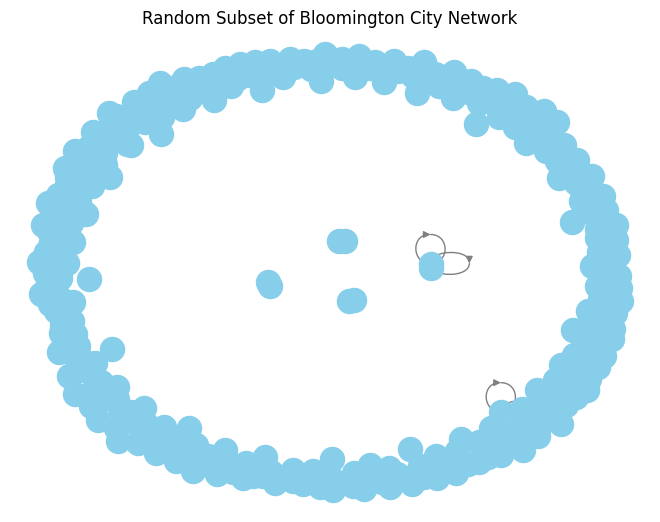

In [ ]:
# Visualization of a random subset of the Bloomington city network for network visualization example

city = 'Bloomington'
print(f"{city} stats:\n")
G, city_nodes_info, city_edges_info = graph_loader(city)

sampled_nodes = random.sample(list(G.nodes()), 300)

sub_G = G.subgraph(sampled_nodes)

nx.draw(sub_G, node_color='skyblue', edge_color='gray')
plt.title("Random Subset of Bloomington City Network")
plt.show()

In [143]:
# City Degree, Betweenness, and Kadabra Betweenness Info:
df = pd.DataFrame({
    'city': city_measures.keys(),
    'Degree': [city_measures[city]['top_degree'] for city in city_measures.keys()],
    'Betweenness': [city_measures[city]['top_betweenness_score'] for city in city_measures.keys()],
    'Kadabra Betweenness': [city_measures[city]['top_k_betweenness_score'] for city in city_measures.keys()]})
df

,city,Degree,Betweenness,Kadabra Betweenness
0,Indianapolis,26,0.229661,0.490617
1,Fort Wayne,16,0.211560,0.454764
2,Evansville,12,0.255014,0.538035
3,South Bend,12,0.225708,0.461328
4,Fishers,14,0.254296,0.682235
5,Carmel,18,0.323009,0.818418
6,Bloomington,14,0.178829,0.411819
7,Hammond,12,0.231795,0.497570
8,Noblesville,10,0.419404,0.827670
9,Lafayette,13,0.163130,0.383932


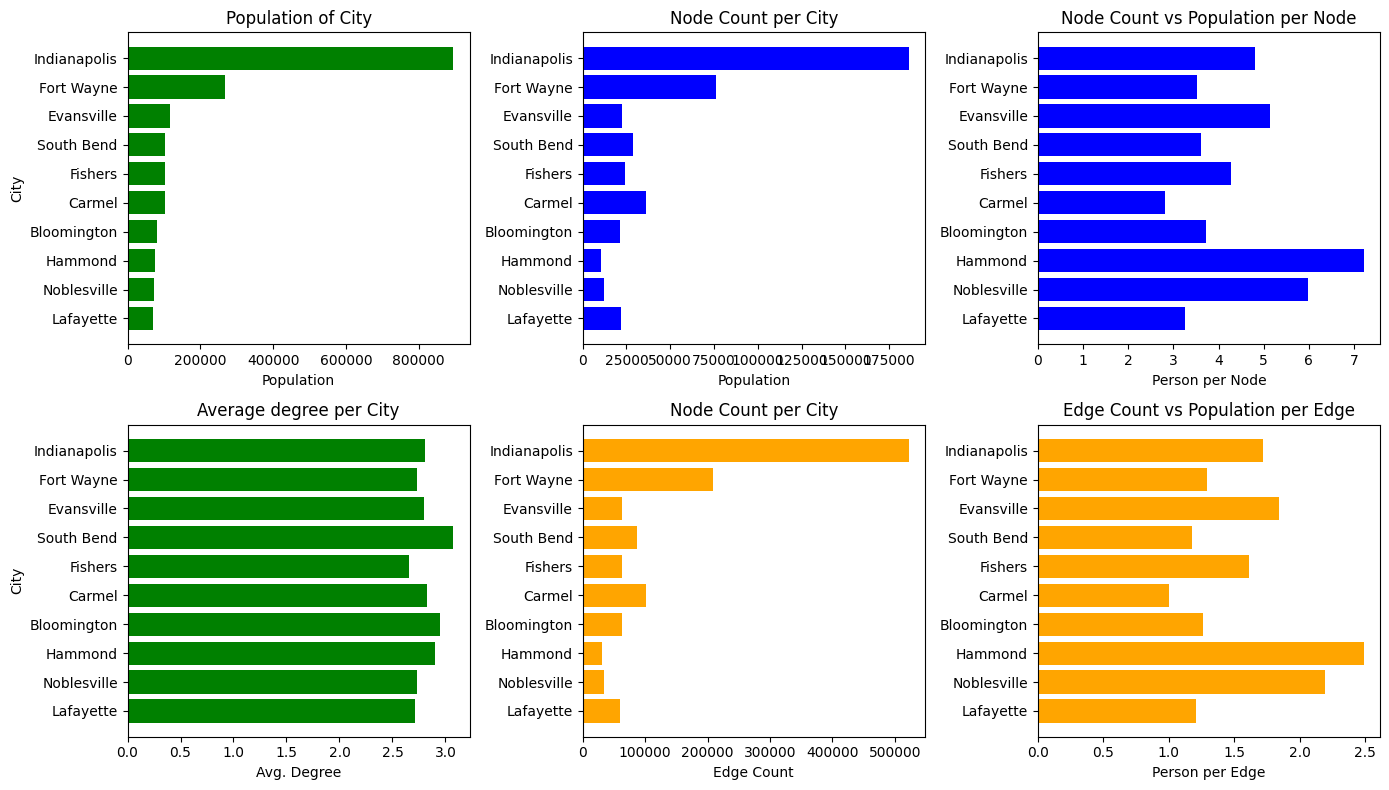

In [ ]:
# Summary visualization of six subplots
# Compares population, average degree, node count, edge count, and their ratios
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

axs[0, 0].barh(city_degree_info['city'], city_degree_info['population'], color='green')
axs[0, 0].invert_yaxis()
axs[0, 0].set_title('Population of City')
axs[0, 0].set_xlabel('Population')
axs[0, 0].set_ylabel('City')

axs[0, 1].barh(city_degree_info['city'], city_degree_info['node_count'], color='blue')
axs[0, 1].invert_yaxis()
axs[0, 1].set_title('Node Count per City')
axs[0, 1].set_xlabel('Population')

axs[0, 2].barh(city_degree_info['city'], city_degree_info['population']/city_degree_info['node_count'], color='blue')
axs[0, 2].invert_yaxis()
axs[0, 2].set_title('Node Count vs Population per Node')
axs[0, 2].set_xlabel('Person per Node')

axs[1, 0].barh(city_degree_info['city'], city_degree_info['edge_count']/city_degree_info['node_count'], color='green')
axs[1, 0].invert_yaxis()
axs[1, 0].set_title('Average degree per City')
axs[1, 0].set_xlabel('Avg. Degree')
axs[1, 0].set_ylabel('City')

axs[1, 1].barh(city_degree_info['city'], city_degree_info['edge_count'], color='orange')
axs[1, 1].invert_yaxis()
axs[1, 1].set_title('Node Count per City')
axs[1, 1].set_xlabel('Edge Count')

axs[1, 2].barh(city_degree_info['city'], city_degree_info['population']/city_degree_info['edge_count'], color='orange')
axs[1, 2].invert_yaxis()
axs[1, 2].set_title('Edge Count vs Population per Edge')
axs[1, 2].set_xlabel('Person per Edge')

plt.tight_layout()
plt.show()

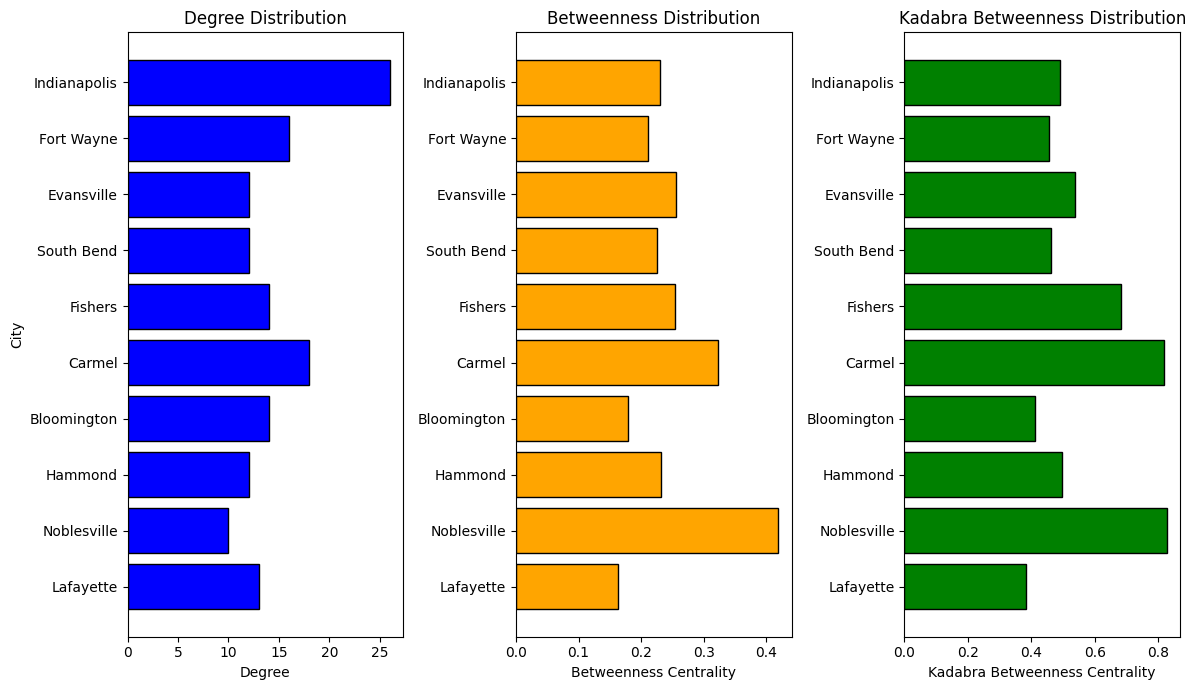

In [ ]:
# Visualization of three subplots comparing degree, betweenness, and kadabra betweenness

fig, axs = plt.subplots(1, 3, figsize=(12, 7))

axs[0].barh(city_degree_info['city'], city_degree_info['degree'], color='blue', edgecolor='black')
axs[0].invert_yaxis()
axs[0].set_title('Degree Distribution')
axs[0].set_xlabel('Degree')
axs[0].set_ylabel('City')

axs[1].barh(city_betweenness_info['city'], city_betweenness_info['betweenness'], color='orange', edgecolor='black')
axs[1].invert_yaxis()
axs[1].set_title('Betweenness Distribution')
axs[1].set_xlabel('Betweenness Centrality')

axs[2].barh(city_k_betweenness_info['city'], city_k_betweenness_info['kadabra_betweenness'], color='green', edgecolor='black')
axs[2].invert_yaxis()
axs[2].set_title('Kadabra Betweenness Distribution')
axs[2].set_xlabel('Kadabra Betweenness Centrality')
plt.tight_layout()
plt.show()

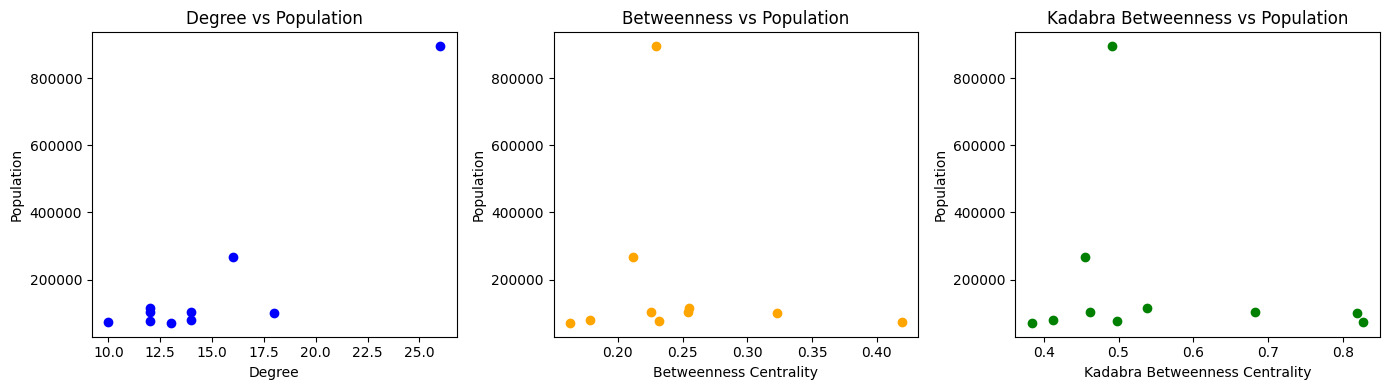

In [ ]:
# Scatter plots comparing degree, betweenness, and kadabra betweenness against population

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].scatter(city_degree_info['degree'], city_degree_info['population'], color='blue')
axs[0].set_title('Degree vs Population')
axs[0].set_xlabel('Degree')
axs[0].set_ylabel('Population')

axs[1].scatter(city_betweenness_info['betweenness'], city_betweenness_info['population'], color='orange')
axs[1].set_title('Betweenness vs Population')
axs[1].set_xlabel('Betweenness Centrality')
axs[1].set_ylabel('Population')

axs[2].scatter(city_k_betweenness_info['kadabra_betweenness'], city_k_betweenness_info['population'], color='green')
axs[2].set_title('Kadabra Betweenness vs Population')
axs[2].set_xlabel('Kadabra Betweenness Centrality')
axs[2].set_ylabel('Population')

plt.tight_layout()
plt.show()

In [ ]:
# Showcase of top nodes that are buildings for degree, betweenness, and kadabra betweenness

print(f"Top Degree Nodes that are buildings: {city_degree_info[city_degree_info['building'].notna()][['city', 'name', 'building']]}")
print(f"\nTop Betweenness Nodes that are buildings: {city_betweenness_info[city_betweenness_info['building'].notna()][['city', 'name', 'building']]}")
print(f"\nTop Kadabra Betweenness Nodes that are buildings: {city_k_betweenness_info[city_k_betweenness_info['building'].notna()][['city', 'name', 'building']]}")

Top Degree Nodes that are buildings:           city                      name building
8  Noblesville  The Lodge at Forest Park      yes

Top Betweenness Nodes that are buildings: Empty DataFrame
Columns: [city, name, building]
Index: []

Top Kadabra Betweenness Nodes that are buildings: Empty DataFrame
Columns: [city, name, building]
Index: []


In [ ]:
# Showcase of top nodes that are shops for degree, betweenness, and kadabra betweenness

print(f"Top Degree Nodes that are shops: {city_degree_info[city_degree_info['shop'].notna()][['city', 'name', 'shop']]}")
print(f"\nTop Betweenness Nodes that are shops: {city_betweenness_info[city_betweenness_info['shop'].notna()][['city', 'name', 'shop']]}")
print(f"\nTop Kadabra Betweenness Nodes that are shops: {city_k_betweenness_info[city_k_betweenness_info['shop'].notna()][['city', 'name', 'shop']]}")

Top Degree Nodes that are shops: Empty DataFrame
Columns: [city, name, shop]
Index: []

Top Betweenness Nodes that are shops:      city name   shop
5  Carmel  DSW  shoes

Top Kadabra Betweenness Nodes that are shops:       city                    name     shop
4  Fishers  Carroll Wine & Spirits  alcohol


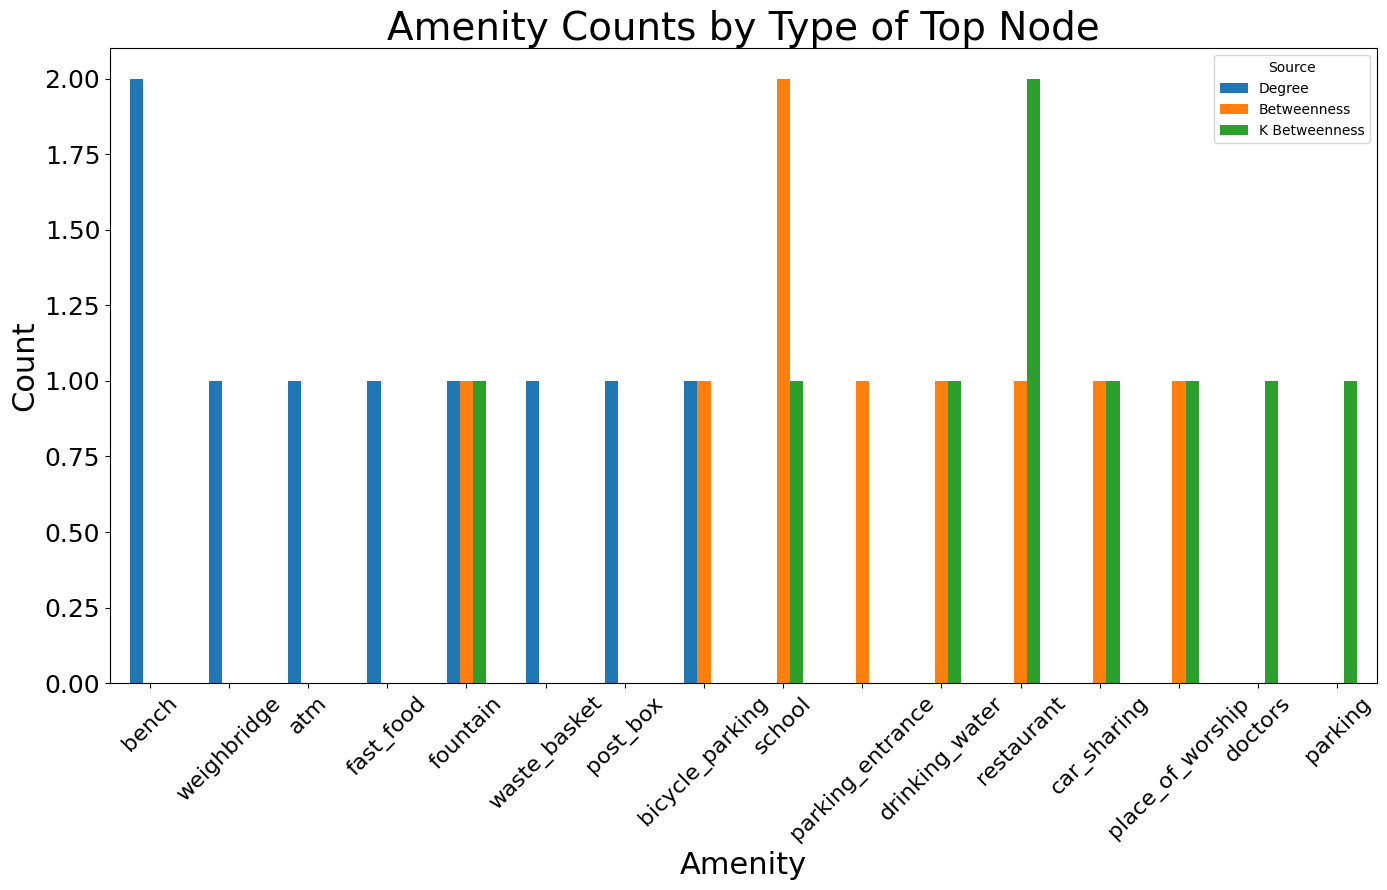

In [ ]:
# Visualization comparing the types of amenities for the top nodes in degree, betweenness, and kadabra betweenness

counts1 = city_degree_info['amenity'].value_counts().rename('Degree')
counts2 = city_betweenness_info['amenity'].value_counts().rename('Betweenness')
counts3 = city_k_betweenness_info['amenity'].value_counts().rename('K Betweenness')

combined = pd.concat([counts1, counts2, counts3], axis=1)

fig, ax = plt.subplots(figsize=(14, 9))
combined.plot(kind='bar', ax=ax)

ax.set_title('Amenity Counts by Type of Top Node', fontsize=28)
ax.set_xlabel('Amenity', fontsize=22)
ax.set_ylabel('Count', fontsize=22)

plt.setp(ax.get_xticklabels(), rotation=45, fontsize=16) 
plt.setp(ax.get_yticklabels(), fontsize=18)

ax.legend(title='Source')

fig.tight_layout() 
plt.show()

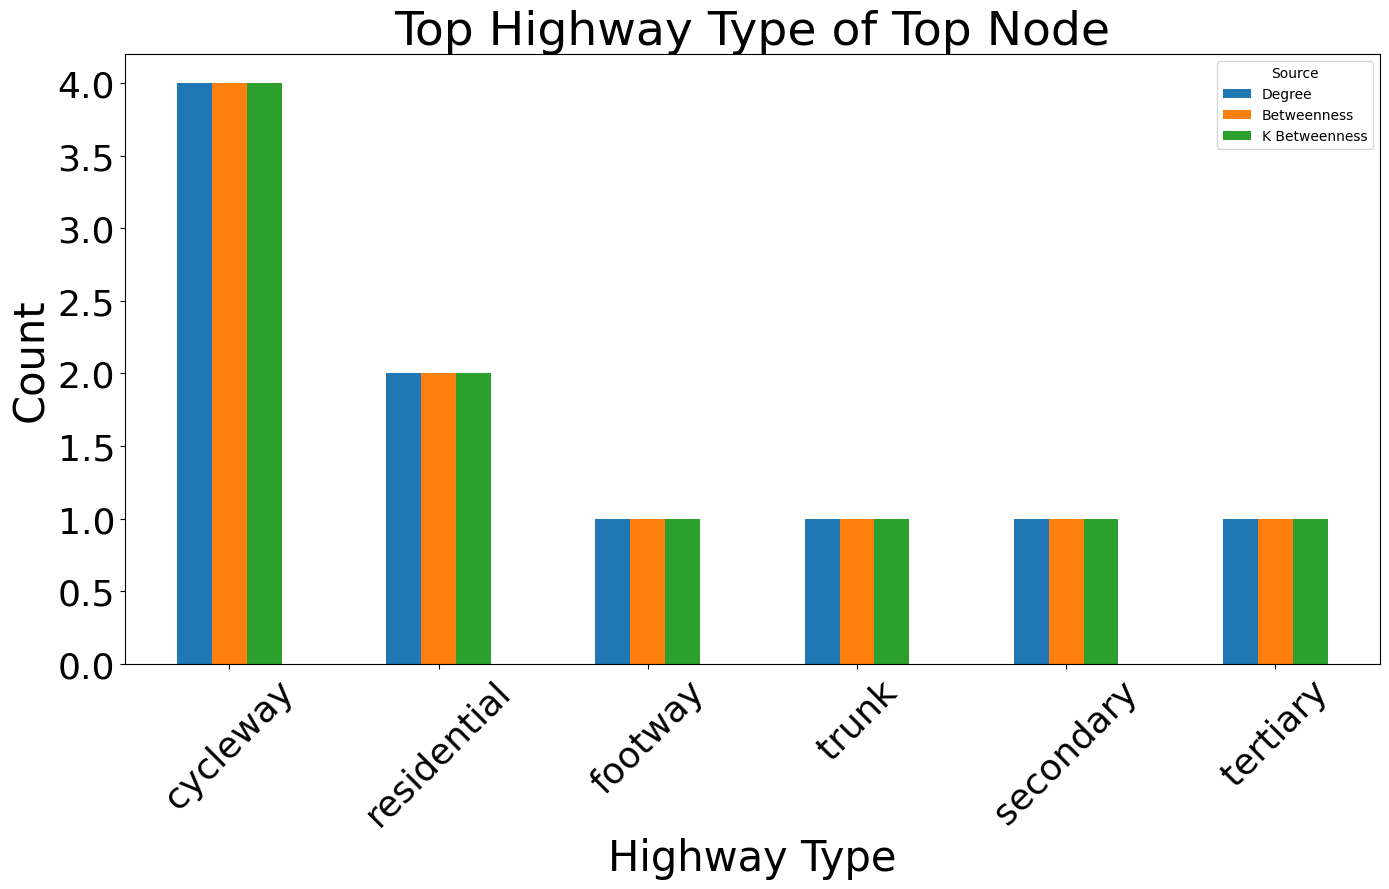

In [ ]:
# Visualization comparing the types of highways for the top nodes in degree, betweenness, and kadabra betweenness

counts1 = city_degree_info['top_highway_type'].value_counts().rename('Degree')
counts2 = city_betweenness_info['top_highway_type'].value_counts().rename('Betweenness')
counts3 = city_k_betweenness_info['top_highway_type'].value_counts().rename('K Betweenness')

combined = pd.concat([counts1, counts2, counts3], axis=1)

fig, ax = plt.subplots(figsize=(14, 9))
combined.plot(kind='bar', ax=ax)

ax.set_title('Top Highway Type of Top Node', fontsize=34)
ax.set_xlabel('Highway Type', fontsize=30)
ax.set_ylabel('Count', fontsize=30)

plt.setp(ax.get_xticklabels(), rotation=45, fontsize=26) 
plt.setp(ax.get_yticklabels(), fontsize=26)

ax.legend(title='Source')

fig.tight_layout() 
plt.show()

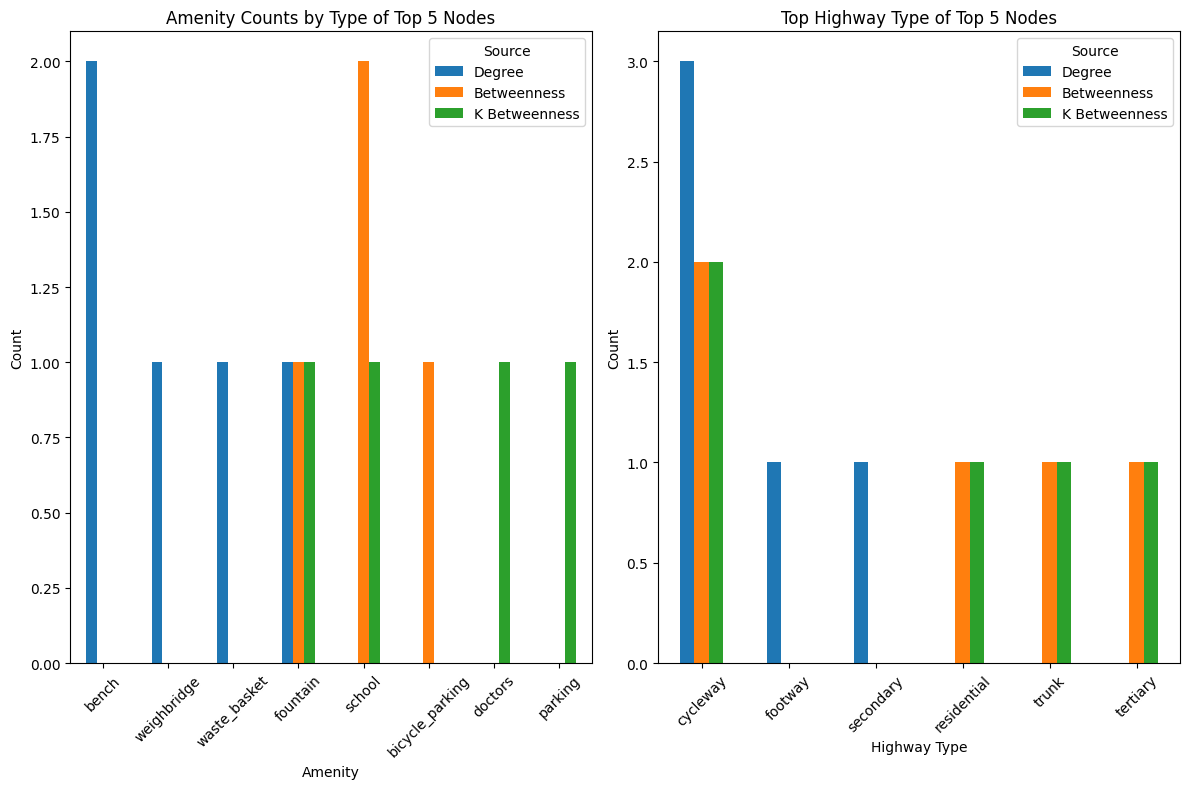

In [ ]:
# Visualization comparing the types of amenities and highways for the top 5 nodes in degree, betweenness, and kadabra betweenness

fig, axs = plt.subplots(1, 2, figsize=(12, 8))

top5_degree = city_degree_info.nlargest(5, 'degree')
top5_betweenness = city_betweenness_info.nlargest(5, 'betweenness')
top5_k_betweenness = city_k_betweenness_info.nlargest(5, 'kadabra_betweenness')

counts1 = top5_degree['amenity'].value_counts().rename('Degree')
counts2 = top5_betweenness['amenity'].value_counts().rename('Betweenness')
counts3 = top5_k_betweenness['amenity'].value_counts().rename('K Betweenness')

combined = pd.concat([counts1, counts2, counts3], axis=1)

combined.plot(kind='bar', ax=axs[0])

axs[0].set_title('Amenity Counts by Type of Top 5 Nodes')
axs[0].set_xlabel('Amenity')
axs[0].set_ylabel('Count')

plt.setp(axs[0].get_xticklabels(), rotation=45) 

axs[0].legend(title='Source')

fig.tight_layout() 

counts1 = top5_degree['top_highway_type'].value_counts().rename('Degree')
counts2 = top5_betweenness['top_highway_type'].value_counts().rename('Betweenness')
counts3 = top5_k_betweenness['top_highway_type'].value_counts().rename('K Betweenness')

combined = pd.concat([counts1, counts2, counts3], axis=1)

combined.plot(kind='bar', ax=axs[1])

axs[1].set_title('Top Highway Type of Top 5 Nodes')
axs[1].set_xlabel('Highway Type')
axs[1].set_ylabel('Count')

plt.setp(axs[1].get_xticklabels(), rotation=45) 

axs[1].legend(title='Source')

fig.tight_layout()
plt.show()